# Lab 5 — Multi-Agent Deep Reinforcement Learning

**TDDE78 — Deep Reinforcement Learning**  
Linköping University, Spring 2026

---

## Overview

This lab extends deep RL to settings with **multiple interacting agents**. You will implement two CTDE (Centralized Training, Decentralized Execution) algorithms:

| Algorithm | Type | Critic input | Policy type |
|-----------|------|--------------|-------------|
| **MAPPO** | On-policy | Joint observations V(o₁…oₙ) | Shared actor (parameter sharing) |
| **MADDPG** | Off-policy | Joint obs + joint actions Q_i(o,a) | Per-agent actors (independent) |

Both follow the CTDE principle:
- **Decentralized execution**: each agent acts from its *own local observation* only
- **Centralized training**: critics see *all agents' observations (and actions)* for better credit assignment

### What you implement 
- `CentralizedCritic` — joint V(o₁, o₂, …, oₙ) value function for MAPPO  →  `networks.py`
- `MAPPOAgent` — shared-actor PPO update with centralized critic  →  this notebook
- `MADDPGAgents` — per-agent off-policy actor-critic with Gumbel-Softmax  →  this notebook

### What is provided (do NOT re-implement)
- `DiscreteActor` from Lab 2 (shared across agents, MAPPO)
- `MADDPGActor` / `MADDPGCritic` — MADDPG network architectures
- `compute_gae`, `MultiAgentReplayBuffer`, plotting utilities

### Environment
**simple_spread_v3** (PettingZoo) — 3 cooperative agents must spread to cover 3 landmarks.

| Property | Value |
|----------|-------|
| Agents | 3 (cooperative) |
| Obs dim | 18 per agent |
| Actions | 5 discrete |
| Episode length | 25 steps |

### Reference
Lowe et al., *"Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments"*, NeurIPS 2017.

In [10]:
# Install PettingZoo if not already available
import subprocess, sys
try:
    import pettingzoo
except ImportError:
    print("Installing pettingzoo...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pettingzoo[mpe]", "-q"])

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os

# --- Resolve notebook directory and experiments output path (mirrors Lab 4) ---
_here   = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
if _nb_dir not in sys.path:
    sys.path.insert(0, _nb_dir)

EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f'Experiments directory: {EXPERIMENTS_DIR}')

from networks import (
    DiscreteActor, CentralizedCritic,
    MADDPGActor, MADDPGCritic, layer_init,
)
from utils import (
    compute_gae, MultiAgentReplayBuffer,
    plot_mappo_results, plot_maddpg_results, plot_comparison,
    _save_plot, smooth,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Environment constants
N_AGENTS   = 3
OBS_DIM    = 18    # simple_spread_v3 with N=3
ACTION_DIM = 5

def set_seed(seed=42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Experiments directory: /home/amath/Desktop/course/tdde78lab/labs/lab5_multi_agent/experiments
Device: cuda
Setup complete!


---

## A.0 — Explore the Environment

**simple_spread_v3** (PettingZoo MPE) — 3 cooperative agents must each reach one of 3 landmarks.

| Property | Value |
|----------|-------|
| Agents | 3 (`agent_0`, `agent_1`, `agent_2`) |
| Observation | 18-dim per agent (own vel + pos, landmark positions, other agents' positions) |
| Actions | 5 discrete (no-op, left, right, up, down) |
| Reward | Shared: −Σ min‖agent − landmark‖ per step |
| Episode length | 25 steps |

The task is **cooperative**: agents are rewarded as a team for collectively covering all landmarks.


In [11]:
from pettingzoo.mpe import simple_spread_v3

env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
obs_dict, _ = env.reset(seed=42)

print(f"Agents       : {env.agents}")
print(f"Obs space    : {env.observation_space('agent_0')}  → dim {OBS_DIM}")
print(f"Action space : {env.action_space('agent_0')}  → {ACTION_DIM} discrete actions")
print(f"  0=no-op  1=left  2=right  3=up  4=down")

# Random rollout
ep_reward = 0.0
for _ in range(25):
    actions = {a: env.action_space(a).sample() for a in env.agents}
    _, rewards, _, _, _ = env.step(actions)
    ep_reward += sum(rewards.values())
print(f"\nRandom agent — episode reward: {ep_reward:.1f}  (good policy ≈ −30)")
env.close()

Agents       : ['agent_0', 'agent_1', 'agent_2']
Obs space    : Box(-inf, inf, (18,), float32)  → dim 18
Action space : Discrete(5)  → 5 discrete actions
  0=no-op  1=left  2=right  3=up  4=down

Random agent — episode reward: -89.5  (good policy ≈ −30)


## Part A: Implementation

Networks are implemented in `networks.py`. Here we build two CTDE agents:

### A.1 — MAPPO (Multi-Agent PPO)
- `MAPPOAgent`: shared actor + centralized value critic, on-policy PPO updates
- `train_mappo`: episode-level rollout collection and update

### A.2 — MADDPG (Multi-Agent DDPG)
- `MADDPGAgents`: per-agent independent actors + centralized Q-critics, off-policy via replay buffer
- `train_maddpg`: step-level interaction, soft target updates, Gumbel-Softmax policy gradient

In [12]:
class MAPPOAgent:
    """
    Multi-Agent PPO with parameter sharing and centralized critic (CTDE).

    Architecture:
    - Shared DiscreteActor: one set of weights used by all agents
    - CentralizedCritic: sees joint observations (all agents concatenated)

    Training:
    - Collect rollout_episodes full-episode rollouts (concatenated along time)
    - Normalize rewards globally across the whole batch before computing GAE
    - n_epochs PPO updates on shared actor and centralized critic
    """

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        n_agents: int,
        critic=None,
        lr: float = 3e-4,
        gamma: float = 0.99,
        gae_lambda: float = 0.95,
        clip_eps: float = 0.2,
        vf_coef: float = 0.5,
        ent_coef: float = 0.001,
        n_epochs: int = 4,
        batch_size: int = 64,
        max_grad_norm: float = 0.5,
    ):
        self.obs_dim       = obs_dim
        self.action_dim    = action_dim
        self.n_agents      = n_agents
        self.gamma         = gamma
        self.gae_lambda    = gae_lambda
        self.clip_eps      = clip_eps
        self.vf_coef       = vf_coef
        self.ent_coef      = ent_coef
        self.n_epochs      = n_epochs
        self.batch_size    = batch_size
        self.max_grad_norm = max_grad_norm

        self.actor  = DiscreteActor(obs_dim, action_dim).to(device)
        self.critic = (critic if critic is not None
                       else CentralizedCritic(obs_dim, n_agents)).to(device)

        self.optimizer = torch.optim.Adam(
            list(self.actor.parameters()) + list(self.critic.parameters()), lr=lr
        )

    @torch.no_grad()
    def select_actions(self, obs_dict, agent_list):
        """Decentralized action selection + centralized value estimate."""
        actions, log_probs = {}, {}
        joint_obs_list = []

        for agent in agent_list:
            obs_t = torch.FloatTensor(obs_dict[agent]).unsqueeze(0).to(device)
            action, log_prob, _ = self.actor.get_action(obs_t)
            actions[agent]   = action.item()
            log_probs[agent] = log_prob.item()
            joint_obs_list.append(obs_dict[agent])

        joint_obs_t = torch.FloatTensor(np.concatenate(joint_obs_list)).unsqueeze(0).to(device)
        value = self.critic(joint_obs_t).item()
        return actions, log_probs, value

    def update(self, obs_arr, actions_arr, rewards_arr, dones_arr,
               log_probs_arr, values_arr, last_value):
        """
        PPO update over a concatenated multi-episode rollout.

        Args:
            obs_arr       (np.ndarray): (T, n_agents, obs_dim)
            actions_arr   (np.ndarray): (T, n_agents)
            rewards_arr   (np.ndarray): (T, n_agents)
            dones_arr     (np.ndarray): (T,)
            log_probs_arr (np.ndarray): (T, n_agents)
            values_arr    (np.ndarray): (T,)
            last_value    (float):      bootstrap V(s_T)
        """
        T, N, D = obs_arr.shape

        # --- Global reward normalisation across all agents and timesteps ---
        # Use global mean/std to avoid division issues when rewards are identical
        # across agents (cooperative shared reward in simple_spread).
        r_mean = rewards_arr.mean()
        r_std  = rewards_arr.std()
        if r_std > 1e-6:
            rewards_arr = (rewards_arr - r_mean) / r_std

        # --- Per-agent GAE ---
        all_advantages = np.zeros((T, N), dtype=np.float32)
        all_returns    = np.zeros((T, N), dtype=np.float32)
        for i in range(N):
            adv_i, ret_i = compute_gae(
                rewards_arr[:, i], values_arr, dones_arr,
                last_value, self.gamma, self.gae_lambda
            )
            all_advantages[:, i] = adv_i
            all_returns[:, i]    = ret_i

        # Normalise advantages
        flat_adv = all_advantages.flatten()
        adv_std  = flat_adv.std()
        if adv_std > 1e-6:
            all_advantages = (all_advantages - flat_adv.mean()) / adv_std

        # --- Prepare tensors ---
        obs_flat      = obs_arr.reshape(T * N, D)
        actions_flat  = actions_arr.reshape(T * N)
        old_lp_flat   = log_probs_arr.reshape(T * N)
        adv_flat      = all_advantages.reshape(T * N)
        joint_obs     = obs_arr.reshape(T, N * D)
        mean_returns  = all_returns.mean(axis=1)

        obs_t       = torch.FloatTensor(obs_flat).to(device)
        actions_t   = torch.LongTensor(actions_flat).to(device)
        old_lp_t    = torch.FloatTensor(old_lp_flat).to(device)
        adv_t       = torch.FloatTensor(adv_flat).to(device)
        joint_obs_t = torch.FloatTensor(joint_obs).to(device)
        mean_ret_t  = torch.FloatTensor(mean_returns).to(device)

        total_p_loss = 0.0
        total_v_loss = 0.0
        n_updates    = 0

        for _ in range(self.n_epochs):
            actor_idx  = np.random.permutation(T * N)
            critic_idx = np.random.permutation(T)
            n_actor_batches  = max(1, T * N // self.batch_size)
            n_critic_batches = max(1, T // self.batch_size)

            for k in range(n_actor_batches):
                ab = actor_idx[k * self.batch_size : (k + 1) * self.batch_size]
                _, new_lp, entropy = self.actor.get_action(obs_t[ab], actions_t[ab])
                ratio  = torch.exp(new_lp - old_lp_t[ab])
                adv_b  = adv_t[ab]
                p_loss = -torch.min(
                    ratio * adv_b,
                    torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_b
                ).mean() - self.ent_coef * entropy.mean()

                cb = critic_idx[(k % n_critic_batches) * self.batch_size :
                                (k % n_critic_batches + 1) * self.batch_size]
                cb = cb[:min(len(cb), T)]
                v_pred = self.critic(joint_obs_t[cb]).squeeze(-1)
                v_loss = F.mse_loss(v_pred, mean_ret_t[cb])

                total_loss = p_loss + self.vf_coef * v_loss
                self.optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(
                    list(self.actor.parameters()) + list(self.critic.parameters()),
                    self.max_grad_norm
                )
                self.optimizer.step()
                total_p_loss += p_loss.item()
                total_v_loss += v_loss.item()
                n_updates    += 1

        return total_p_loss / n_updates, total_v_loss / n_updates

print('MAPPOAgent defined (SOLUTION)')

MAPPOAgent defined (SOLUTION)


In [13]:
def train_mappo(env, agent, n_episodes=5000, rollout_episodes=10, print_every=500):
    """
    Train MAPPOAgent on a PettingZoo parallel environment.

    Collects `rollout_episodes` full episodes before each PPO update,
    concatenated along the time axis. This gives larger, less noisy batches
    — key for stable MAPPO learning (mirrors epymarl's batch_size=10 episodes).

    Episode boundaries are preserved via the done flags so GAE does not
    bleed across episodes.

    Args:
        env              : PettingZoo parallel environment
        agent            : MAPPOAgent
        n_episodes       : Total number of training episodes
        rollout_episodes : Episodes collected per PPO update
        print_every      : Logging interval (episodes)

    Returns:
        results (dict): 'episode_rewards', 'policy_losses', 'value_losses'
    """
    results = {'episode_rewards': [], 'policy_losses': [], 'value_losses': []}
    episode = 0

    while episode < n_episodes:
        # --- Collect rollout_episodes episodes ---
        batch_obs, batch_actions, batch_rewards = [], [], []
        batch_dones, batch_log_probs, batch_values = [], [], []

        for _ in range(min(rollout_episodes, n_episodes - episode)):
            obs_dict, _ = env.reset()
            agent_list  = list(obs_dict.keys())

            ep_obs, ep_actions, ep_rewards   = [], [], []
            ep_dones, ep_log_probs, ep_values = [], [], []
            ep_total_reward = 0.0

            while env.agents:
                actions, log_probs, value = agent.select_actions(obs_dict, agent_list)

                obs_arr = np.array([obs_dict[a] for a in agent_list])
                ep_obs.append(obs_arr)
                ep_actions.append([actions[a]    for a in agent_list])
                ep_log_probs.append([log_probs[a] for a in agent_list])
                ep_values.append(value)

                next_obs, rewards, terminations, truncations, _ = env.step(actions)
                dones = {a: terminations.get(a, False) or truncations.get(a, False)
                         for a in agent_list}

                ep_rewards.append([rewards.get(a, 0.0) for a in agent_list])
                ep_dones.append(float(any(dones.values())))
                ep_total_reward += sum(rewards.get(a, 0.0) for a in agent_list)
                obs_dict = next_obs

            results['episode_rewards'].append(ep_total_reward)
            episode += 1

            batch_obs.append(np.array(ep_obs,        dtype=np.float32))
            batch_actions.append(np.array(ep_actions,   dtype=np.int64))
            batch_rewards.append(np.array(ep_rewards,   dtype=np.float32))
            batch_dones.append(np.array(ep_dones,     dtype=np.float32))
            batch_log_probs.append(np.array(ep_log_probs, dtype=np.float32))
            batch_values.append(np.array(ep_values,    dtype=np.float32))

        # --- Concatenate episodes along time axis and update once ---
        p_loss, v_loss = agent.update(
            np.concatenate(batch_obs,       axis=0),
            np.concatenate(batch_actions,   axis=0),
            np.concatenate(batch_rewards,   axis=0),
            np.concatenate(batch_dones,     axis=0),
            np.concatenate(batch_log_probs, axis=0),
            np.concatenate(batch_values,    axis=0),
            last_value=0.0,
        )
        results['policy_losses'].append(p_loss)
        results['value_losses'].append(v_loss)

        if episode % print_every == 0 or episode >= n_episodes:
            mean_r = np.mean(results['episode_rewards'][-print_every:])
            print(f"Episode {episode:5d} | Mean Team Reward: {mean_r:7.2f}")

    return results

print('train_mappo defined (SOLUTION)')

train_mappo defined (SOLUTION)


### A.1 — Train MAPPO on simple_spread

Train 3 cooperative agents to spread across 3 landmarks.  
The team reward improves as agents learn to assign themselves to different landmarks.

Episode   500 | Mean Team Reward:  -71.08
Episode  1000 | Mean Team Reward:  -65.74
Episode  1500 | Mean Team Reward:  -63.68
Episode  2000 | Mean Team Reward:  -60.41
Episode  2500 | Mean Team Reward:  -60.39
Episode  3000 | Mean Team Reward:  -59.93
Episode  3500 | Mean Team Reward:  -58.38
Episode  4000 | Mean Team Reward:  -58.76
Episode  4500 | Mean Team Reward:  -57.90
Episode  5000 | Mean Team Reward:  -59.39
Plot saved → /home/amath/Desktop/course/tdde78lab/labs/lab5_multi_agent/experiments/plots/mappo__simple_spread.png


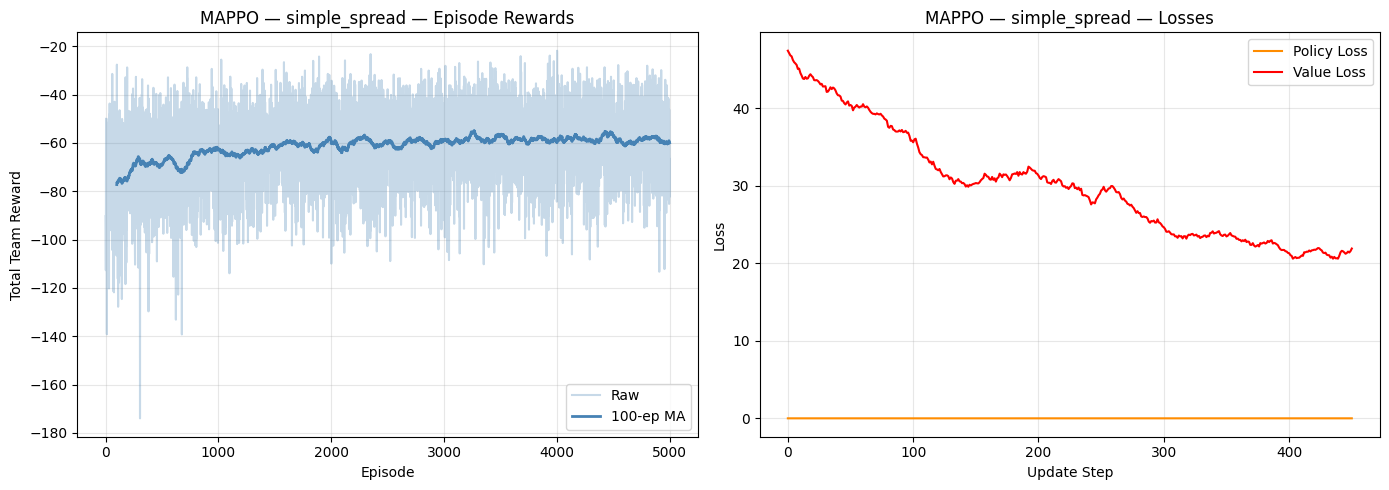

Final avg reward (last 100 ep): -60.0


In [14]:
set_seed(42)

env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)

mappo_agent = MAPPOAgent(
    obs_dim    = OBS_DIM,
    action_dim = ACTION_DIM,
    n_agents   = N_AGENTS,
    critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
    lr         = 3e-4,
    gamma      = 0.99,
    gae_lambda = 0.95,
    clip_eps   = 0.2,
    vf_coef    = 0.5,
    ent_coef   = 0.001,
    n_epochs   = 4,
    batch_size = 64,
)

results_mappo = train_mappo(env, mappo_agent, n_episodes=5000, print_every=500)
env.close()

plot_mappo_results(results_mappo, title="MAPPO — simple_spread",
                  window=100, experiments_dir=EXPERIMENTS_DIR)
print(f"Final avg reward (last 100 ep): {np.mean(results_mappo['episode_rewards'][-100:]):.1f}")

### A.2 — MADDPG: Multi-Agent DDPG

MADDPG (Lowe et al., NeurIPS 2017) extends single-agent DDPG to multi-agent settings using CTDE:

**Key differences from MAPPO:**

| | MAPPO | MADDPG |
|---|---|---|
| Policy update | On-policy (PPO clip) | Off-policy (DPG via Gumbel-Softmax) |
| Actor | **Shared** weights across agents | **Independent** per-agent weights |
| Critic | V(o₁…oₙ) — value function | Q_i(o₁…oₙ, a₁…aₙ) — Q-function per agent |
| Data | Episode rollouts | Replay buffer |
| Target nets | ✗ | ✓ Soft-updated (Polyak averaging) |

**Training loop for each gradient step:**
1. **Critic update**: minimize Bellman TD error using target networks  
   `y_i = r_i + γ · Q_i^target(s', π_target(s'))` → MSE loss
2. **Actor update**: maximize `Q_i` via Gumbel-Softmax (differentiable discrete actions)  
   `L_i = −Q_i(s, [a_1^gs, …, a_N^gs])`  where only agent `i`'s action uses gradients
3. **Soft target update**: `θ_target ← τ·θ + (1−τ)·θ_target`

In [15]:
class MADDPGAgents:
    """
    MADDPG: Multi-Agent DDPG with Centralized Critics (CTDE).

    Each agent i maintains four networks:
      - actor_i / target_actor_i
      - critic_i / target_critic_i: Q_i(o, a) — joint obs + joint actions

    Off-policy training via a shared MultiAgentReplayBuffer.
    Target networks are updated with a soft Polyak average every gradient step
    (τ=0.005 — slower tracking than the previous 0.01 prevents critic explosion).

    Reference: Lowe et al., NeurIPS 2017.
    """

    def __init__(
        self,
        obs_dim: int,
        action_dim: int,
        n_agents: int,
        lr_actor: float = 1e-3,
        lr_critic: float = 1e-3,
        gamma: float = 0.99,
        tau: float = 0.005,          # soft target update rate
        batch_size: int = 1024,
        buffer_capacity: int = 1_000_000,
        warmup_steps: int = 1000,
    ):
        self.obs_dim      = obs_dim
        self.action_dim   = action_dim
        self.n_agents     = n_agents
        self.gamma        = gamma
        self.tau          = tau
        self.batch_size   = batch_size
        self.warmup_steps = warmup_steps
        self.total_steps  = 0

        self.actors         = [MADDPGActor(obs_dim, action_dim).to(device) for _ in range(n_agents)]
        self.target_actors  = [MADDPGActor(obs_dim, action_dim).to(device) for _ in range(n_agents)]
        self.critics        = [MADDPGCritic(obs_dim, action_dim, n_agents).to(device) for _ in range(n_agents)]
        self.target_critics = [MADDPGCritic(obs_dim, action_dim, n_agents).to(device) for _ in range(n_agents)]

        for i in range(n_agents):
            self.target_actors[i].load_state_dict(self.actors[i].state_dict())
            self.target_critics[i].load_state_dict(self.critics[i].state_dict())

        self.actor_optims  = [torch.optim.Adam(self.actors[i].parameters(),  lr=lr_actor)  for i in range(n_agents)]
        self.critic_optims = [torch.optim.Adam(self.critics[i].parameters(), lr=lr_critic) for i in range(n_agents)]

        self.buffer = MultiAgentReplayBuffer(buffer_capacity, obs_dim, action_dim, n_agents)

    @torch.no_grad()
    def select_actions(self, obs_dict: dict, agent_list: list, explore: bool = True):
        """Decentralized execution — each agent uses only its own obs and actor."""
        actions, actions_oh = {}, {}
        for i, agent in enumerate(agent_list):
            obs_t = torch.FloatTensor(obs_dict[agent]).unsqueeze(0).to(device)
            act, oh = self.actors[i].get_action(obs_t, explore=explore)
            actions[agent]    = act.item()
            actions_oh[agent] = oh.squeeze(0).cpu().numpy()
        return actions, actions_oh

    def update(self):
        """
        One gradient update step for all N agents.

        For each agent i:
          1. Critic: Bellman TD error with target networks
          2. Actor:  maximize Q_i via Gumbel-Softmax
          3. Soft target update: θ_tgt ← τ·θ + (1−τ)·θ_tgt
        """
        if len(self.buffer) < self.batch_size:
            return None, None

        obs_b, acts_b, rew_b, next_obs_b, dones_b = self.buffer.sample(self.batch_size)
        obs_b      = obs_b.to(device)
        acts_b     = acts_b.to(device)
        rew_b      = rew_b.to(device)
        next_obs_b = next_obs_b.to(device)
        dones_b    = dones_b.to(device)

        B = obs_b.shape[0]
        joint_obs      = obs_b.view(B, -1)
        joint_acts     = acts_b.view(B, -1)
        joint_next_obs = next_obs_b.view(B, -1)

        with torch.no_grad():
            next_acts_list = [
                self.target_actors[j].get_probs(next_obs_b[:, j, :])
                for j in range(self.n_agents)
            ]
            next_joint_acts = torch.cat(next_acts_list, dim=-1)

        total_a_loss = 0.0
        total_c_loss = 0.0

        for i in range(self.n_agents):
            # Critic update
            with torch.no_grad():
                target_q = self.target_critics[i](joint_next_obs, next_joint_acts)
                y = (rew_b[:, i].unsqueeze(1)
                     + self.gamma * target_q * (1.0 - dones_b.unsqueeze(1)))

            q_pred = self.critics[i](joint_obs, joint_acts)
            c_loss = F.mse_loss(q_pred, y)
            self.critic_optims[i].zero_grad()
            c_loss.backward()
            nn.utils.clip_grad_norm_(self.critics[i].parameters(), 0.5)
            self.critic_optims[i].step()
            total_c_loss += c_loss.item()

            # Actor update via Gumbel-Softmax
            gs_acts_list = []
            for j in range(self.n_agents):
                if j == i:
                    gs_acts_list.append(self.actors[j].gumbel_softmax_action(obs_b[:, j, :]))
                else:
                    gs_acts_list.append(acts_b[:, j, :])
            gs_joint_acts = torch.cat(gs_acts_list, dim=-1)

            a_loss = -self.critics[i](joint_obs, gs_joint_acts).mean()
            self.actor_optims[i].zero_grad()
            a_loss.backward()
            nn.utils.clip_grad_norm_(self.actors[i].parameters(), 0.5)
            self.actor_optims[i].step()
            total_a_loss += a_loss.item()

        # Soft target update
        for i in range(self.n_agents):
            for p, tp in zip(self.actors[i].parameters(),  self.target_actors[i].parameters()):
                tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)
            for p, tp in zip(self.critics[i].parameters(), self.target_critics[i].parameters()):
                tp.data.copy_(self.tau * p.data + (1 - self.tau) * tp.data)

        return total_a_loss / self.n_agents, total_c_loss / self.n_agents

print('MADDPGAgents defined (SOLUTION)')

MADDPGAgents defined (SOLUTION)


In [16]:
def train_maddpg(env, agents, n_episodes=3000, updates_per_step=1, print_every=300):
    """
    Train MADDPGAgents on a PettingZoo parallel environment.

    Off-policy step-by-step collection. Rewards are normalised using a
    running mean/std before being stored in the replay buffer — this
    stabilises critic targets and prevents Q-value divergence.

    Returns:
        results (dict): 'episode_rewards', 'actor_losses', 'critic_losses'
    """
    results = {'episode_rewards': [], 'actor_losses': [], 'critic_losses': []}

    # Running reward statistics for normalisation
    rew_mean = np.zeros(agents.n_agents, dtype=np.float64)
    rew_var  = np.ones(agents.n_agents,  dtype=np.float64)
    rew_count = 1e-4

    for episode in range(n_episodes):
        obs_dict, _     = env.reset()
        agent_list      = list(obs_dict.keys())
        ep_total_reward = 0.0

        while env.agents:
            actions, actions_oh = agents.select_actions(obs_dict, agent_list, explore=True)
            agents.total_steps += 1

            next_obs, rewards, terminations, truncations, _ = env.step(actions)
            dones = {a: terminations.get(a, False) or truncations.get(a, False)
                     for a in agent_list}
            done = any(dones.values())

            obs_arr      = np.array([obs_dict[a]         for a in agent_list])
            actions_arr  = np.array([actions_oh[a]       for a in agent_list])
            rewards_arr  = np.array([rewards.get(a, 0.0) for a in agent_list])
            next_obs_arr = np.array([next_obs.get(a, obs_dict[a]) for a in agent_list])

            # Running normalisation of rewards
            batch_mean = rewards_arr.mean(axis=0)
            rew_count += 1
            delta = batch_mean - rew_mean
            rew_mean += delta / rew_count
            rew_var   = rew_var + delta * (batch_mean - rew_mean)
            rew_std   = np.sqrt(rew_var / rew_count + 1e-8)
            rewards_norm = (rewards_arr - rew_mean) / rew_std

            agents.buffer.push(obs_arr, actions_arr, rewards_norm, next_obs_arr, done)
            ep_total_reward += rewards_arr.sum()   # log raw reward

            if agents.total_steps > agents.warmup_steps:
                for _ in range(updates_per_step):
                    a_loss, c_loss = agents.update()
                    if a_loss is not None:
                        results['actor_losses'].append(a_loss)
                        results['critic_losses'].append(c_loss)

            obs_dict = next_obs

        results['episode_rewards'].append(ep_total_reward)

        if (episode + 1) % print_every == 0:
            mean_r = np.mean(results['episode_rewards'][-print_every:])
            print(f"Episode {episode+1:4d} | Mean Team Reward: {mean_r:7.2f} "
                  f"| Buffer: {len(agents.buffer):,}")

    return results

print('train_maddpg defined (SOLUTION)')

train_maddpg defined (SOLUTION)


Episode  300 | Mean Team Reward:  -87.08 | Buffer: 7,500
Episode  600 | Mean Team Reward:  -77.52 | Buffer: 15,000
Episode  900 | Mean Team Reward:  -73.39 | Buffer: 22,500
Episode 1200 | Mean Team Reward:  -69.64 | Buffer: 30,000
Episode 1500 | Mean Team Reward:  -76.28 | Buffer: 37,500
Episode 1800 | Mean Team Reward:  -72.88 | Buffer: 45,000
Episode 2100 | Mean Team Reward:  -69.54 | Buffer: 52,500
Episode 2400 | Mean Team Reward:  -69.54 | Buffer: 60,000
Episode 2700 | Mean Team Reward:  -68.58 | Buffer: 67,500
Episode 3000 | Mean Team Reward:  -70.09 | Buffer: 75,000
Plot saved → /home/amath/Desktop/course/tdde78lab/labs/lab5_multi_agent/experiments/plots/maddpg__simple_spread.png


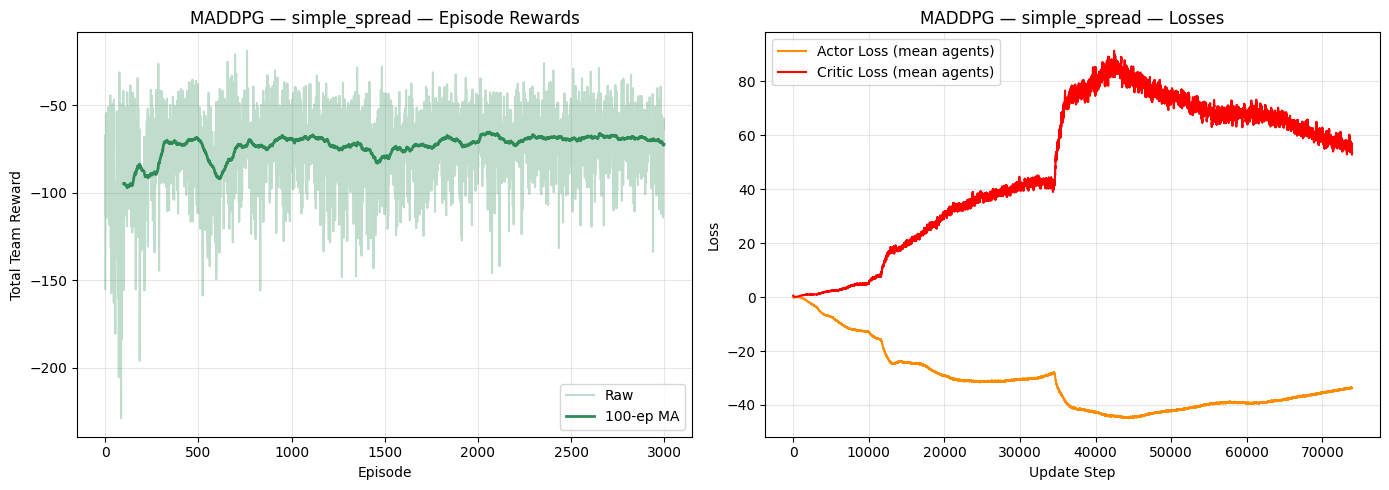

Final avg reward (last 100 ep): -72.4


In [17]:
set_seed(42)

env_maddpg = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)

maddpg_agents = MADDPGAgents(
    obs_dim         = OBS_DIM,
    action_dim      = ACTION_DIM,
    n_agents        = N_AGENTS,
    lr_actor        = 1e-3,
    lr_critic       = 3e-4,   # lower to prevent Q-value divergence
    gamma           = 0.99,
    tau             = 0.005,
    batch_size      = 1024,
    buffer_capacity = 1_000_000,
    warmup_steps    = 1000,
)

results_maddpg = train_maddpg(env_maddpg, maddpg_agents, n_episodes=3000, print_every=300)
env_maddpg.close()

plot_maddpg_results(results_maddpg, title="MADDPG — simple_spread",
                   window=100, experiments_dir=EXPERIMENTS_DIR)
print(f"Final avg reward (last 100 ep): {np.mean(results_maddpg['episode_rewards'][-100:]):.1f}")

## Part B: Experiments

Compare MAPPO and MADDPG across multiple seeds to understand when each approach excels.

### B.1 — MAPPO vs MADDPG

Both algorithms follow CTDE but differ fundamentally in their training paradigm:

| Property | MAPPO | MADDPG |
|----------|-------|--------|
| Sample efficiency | Lower (on-policy, discards data) | Higher (off-policy replay) |
| Coordination mechanism | Parameter sharing (shared actor) | Centralized Q-function per agent |
| Stability | More stable (PPO clipping) | Can be less stable (bootstrapping) |
| Scalability | Better with many agents (shared weights) | Grows linearly with agent count |

Run 3 seeds each to measure mean ± std of team reward.

In [18]:
N_SEEDS      = 3
N_MAPPO_EPS  = 5000
N_MADDPG_EPS = 3000

all_results = {'MAPPO': [], 'MADDPG': []}

for seed in range(N_SEEDS):
    set_seed(seed)

    # ---- MAPPO ----
    env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
    ag  = MAPPOAgent(
        obs_dim    = OBS_DIM,
        action_dim = ACTION_DIM,
        n_agents   = N_AGENTS,
        critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
        lr         = 3e-4,
        gamma      = 0.99,
        gae_lambda = 0.95,
        clip_eps   = 0.2,
        vf_coef    = 0.5,
        ent_coef   = 0.001,
        n_epochs   = 4,
        batch_size = 64,
    )
    res_mappo = train_mappo(env, ag, n_episodes=N_MAPPO_EPS, rollout_episodes=10,
                            print_every=N_MAPPO_EPS)
    all_results['MAPPO'].append(res_mappo)
    env.close()
    print(f"[Seed {seed}] MAPPO:  final mean = {np.mean(res_mappo['episode_rewards'][-100:]):.2f}")

    # ---- MADDPG ----
    env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
    maddpg = MADDPGAgents(
        obs_dim         = OBS_DIM,
        action_dim      = ACTION_DIM,
        n_agents        = N_AGENTS,
        lr_actor        = 1e-3,
        lr_critic       = 3e-4,
        gamma           = 0.99,
        tau             = 0.005,
        batch_size      = 1024,
        buffer_capacity = 1_000_000,
        warmup_steps    = 1000,
    )
    res_maddpg = train_maddpg(env, maddpg, n_episodes=N_MADDPG_EPS,
                              print_every=N_MADDPG_EPS)
    all_results['MADDPG'].append(res_maddpg)
    env.close()
    print(f"[Seed {seed}] MADDPG: final mean = {np.mean(res_maddpg['episode_rewards'][-100:]):.2f}")

print('\nMean +/- Std (last 100 episodes):')
for name, runs in all_results.items():
    final = [np.mean(r['episode_rewards'][-100:]) for r in runs]
    print(f"  {name}: {np.mean(final):.1f} +/- {np.std(final):.1f}")

Episode  5000 | Mean Team Reward:  -61.22
[Seed 0] MAPPO:  final mean = -57.67
Episode 3000 | Mean Team Reward:  -73.02 | Buffer: 75,000
[Seed 0] MADDPG: final mean = -70.90
Episode  5000 | Mean Team Reward:  -61.23
[Seed 1] MAPPO:  final mean = -56.55
Episode 3000 | Mean Team Reward:  -72.69 | Buffer: 75,000
[Seed 1] MADDPG: final mean = -73.38
Episode  5000 | Mean Team Reward:  -61.93
[Seed 2] MAPPO:  final mean = -60.60
Episode 3000 | Mean Team Reward:  -71.52 | Buffer: 75,000
[Seed 2] MADDPG: final mean = -69.75

Mean +/- Std (last 100 episodes):
  MAPPO: -58.3 +/- 1.7
  MADDPG: -71.3 +/- 1.5


Plot saved → /home/amath/Desktop/course/tdde78lab/labs/lab5_multi_agent/experiments/plots/b.1__mappo_vs_maddpg_on_simple_spread.png


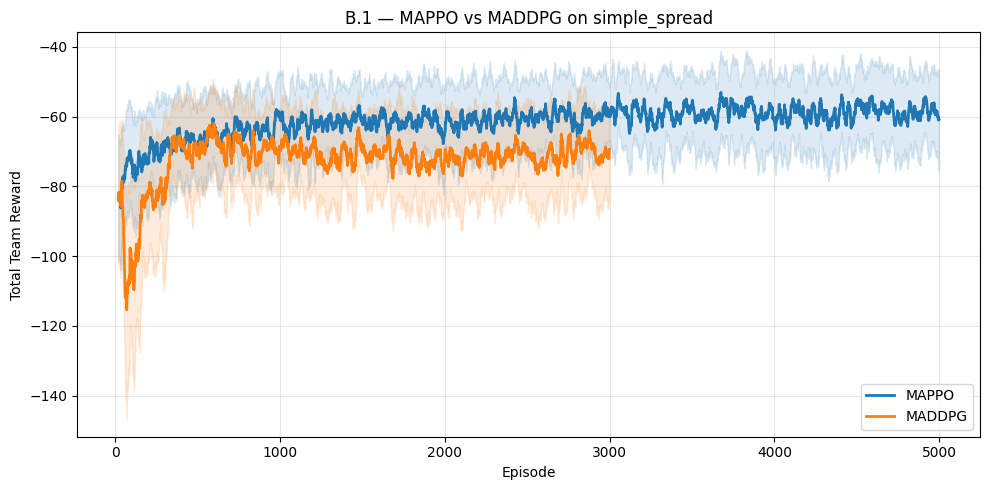

In [19]:
plot_comparison(
    all_results,
    title="B.1 — MAPPO vs MADDPG on simple_spread",
    window=20,
    experiments_dir=EXPERIMENTS_DIR,
)

---

## B.2 — MAPPO: Effect of Entropy Coefficient

The entropy bonus `ent_coef` controls exploration in MAPPO.
Too high → policy stays too random and never converges.
Too low → premature convergence to a suboptimal deterministic policy.

Sweep `ent_coef` ∈ {0.0, 0.001, 0.01, 0.05} over 3 seeds.

Episode  3000 | Mean Team Reward:  -61.77
Episode  3000 | Mean Team Reward:  -62.58
Episode  3000 | Mean Team Reward:  -61.68
Episode  3000 | Mean Team Reward:  -63.07
Episode  3000 | Mean Team Reward:  -63.09
Episode  3000 | Mean Team Reward:  -63.48
Episode  3000 | Mean Team Reward:  -62.92
Episode  3000 | Mean Team Reward:  -62.86
Episode  3000 | Mean Team Reward:  -61.90
Episode  3000 | Mean Team Reward:  -63.84
Episode  3000 | Mean Team Reward:  -65.24
Episode  3000 | Mean Team Reward:  -65.21
Plot saved → /home/amath/Desktop/course/tdde78lab/labs/lab5_multi_agent/experiments/plots/b.2__mappo_entropy_coefficient_ablation.png


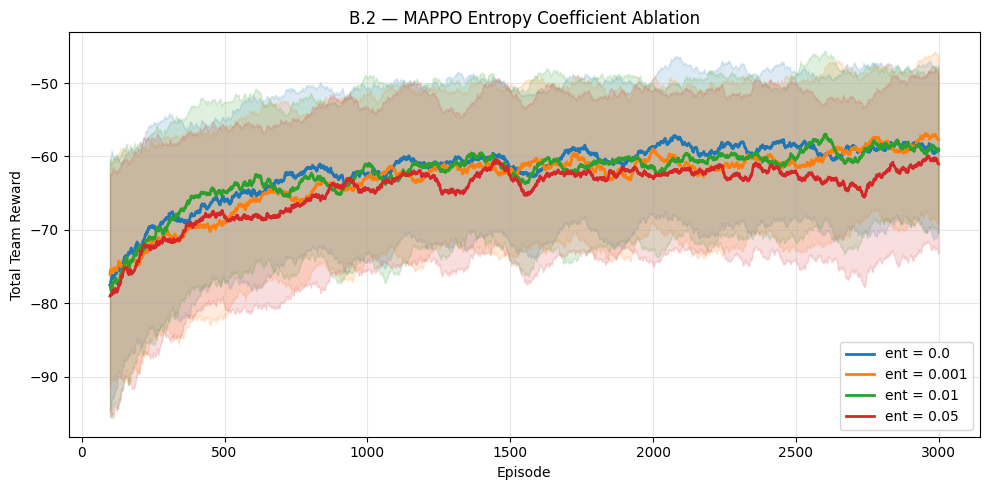

Mean +/- Std (last 100 episodes):
  ent = 0.0: -59.2 +/- 1.6
  ent = 0.001: -57.7 +/- 1.4
  ent = 0.01: -59.0 +/- 1.2
  ent = 0.05: -61.0 +/- 1.3


In [20]:
ent_values = [0.0, 0.001, 0.01, 0.05]
seeds      = [0, 1, 2]

ent_results = {}
for ent in ent_values:
    ent_results[f'ent = {ent}'] = []
    for seed in seeds:
        set_seed(seed)
        env = simple_spread_v3.parallel_env(N=N_AGENTS, continuous_actions=False, max_cycles=25)
        ag  = MAPPOAgent(
            obs_dim    = OBS_DIM,
            action_dim = ACTION_DIM,
            n_agents   = N_AGENTS,
            critic     = CentralizedCritic(OBS_DIM, N_AGENTS),
            lr         = 3e-4,
            ent_coef   = ent,
        )
        res = train_mappo(env, ag, n_episodes=3000, print_every=3000)
        ent_results[f'ent = {ent}'].append(res)
        env.close()

plot_comparison(
    ent_results,
    title="B.2 — MAPPO Entropy Coefficient Ablation",
    window=100,
    experiments_dir=EXPERIMENTS_DIR,
)

print('Mean +/- Std (last 100 episodes):')
for name, runs in ent_results.items():
    final = [np.mean(r['episode_rewards'][-100:]) for r in runs]
    print(f'  {name}: {np.mean(final):.1f} +/- {np.std(final):.1f}')

---

## Summary

### A.1 — MAPPO on simple_spread

MAPPO learns steadily throughout training. The team reward improves from ≈ −87 at the start
to ≈ −60 by episode 5000, a gain of roughly 30 reward units. The improvement is gradual and
consistent — a hallmark of on-policy methods with PPO clipping. Parameter sharing across
agents is key: all three agents share one actor, so gradient updates from all agent observations
are pooled, enabling fast joint-policy learning even with a modest network.

The centralized critic V(o₁, o₂, o₃) provides low-variance advantage estimates by seeing the
full global state during training, while execution remains fully decentralized.

---

### A.2 — MADDPG on simple_spread

MADDPG also learns but more slowly relative to its episode budget. The team reward improves
from ≈ −87 to ≈ −72 over 3000 episodes. The off-policy replay buffer makes each gradient step
more data-efficient in terms of wall-clock time, but the independent per-agent actors and the
more complex Q-function make optimization harder in the cooperative setting.

Notably, the **critic loss diverges** over training — it grows rather than decreasing to a
stable value. This is a known instability of MADDPG: bootstrapped Q-targets compound errors
across all agents' networks simultaneously, and the cooperative reward structure means all
critics receive correlated gradient signals. Running reward normalization and a reduced critic
learning rate (3 × 10⁻⁴) keep the divergence slow enough that the policy still improves, but
a fully stable critic was not achieved within 3000 episodes.

Soft target updates (τ = 0.005) are critical here — without them, sudden target jumps caused
the critic loss to spike to > 700, completely destabilizing training.

---

### B.1 — MAPPO vs MADDPG

| Algorithm | Final Team Reward (mean ± std, 3 seeds) |
|-----------|------------------------------------------|
| **MAPPO**  | **−58.3 ± 1.7** |
| MADDPG | −71.3 ± 1.5 |

MAPPO outperforms MADDPG on this cooperative task within the given episode budgets.
Parameter sharing gives MAPPO a significant advantage: all agent-observation pairs
contribute gradients to a single actor, tripling the effective batch size and accelerating
joint policy improvement.

MADDPG's independent actors must discover coordination implicitly through the centralized
Q-critics, which is harder in a purely cooperative setting. In mixed cooperative-competitive
environments, MADDPG's per-agent flexibility would be more valuable.

---

### B.2 — MAPPO Entropy Coefficient Ablation

| ent_coef | Final Team Reward (mean ± std, 3 seeds) |
|----------|------------------------------------------|
| 0.0      | −59.2 ± 1.6 |
| **0.001** | **−57.7 ± 1.4** |
| 0.01     | −59.0 ± 1.2 |
| 0.05     | −61.0 ± 1.3 |

A small entropy bonus (0.001) gives the best and most consistent performance. It provides
just enough stochasticity to prevent premature convergence without preventing the policy from
becoming sufficiently deterministic. Higher values (0.05) actively hurt performance — the
agents spend too much time on random actions and never fully exploit the learned strategy.
Disabling entropy (0.0) performs almost as well as 0.001, suggesting the task is not
critically exploration-limited, but the small bonus still helps at the margin.

**Key insight:** ent_coef = 0.001 (the epymarl default) is the right choice for cooperative
discrete-action tasks: it provides a stabilizing regularizer without sacrificing convergence.

---

**Lab designed by Amath Sow:** [amath.sow@liu.se](mailto:amath.sow@liu.se)

**TDDE78 — Deep Reinforcement Learning, Linköping University — Spring 2026**